In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [2]:
dl = pd.read_csv('..\\..\\created_data\\botlowcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dl.head())

dm = pd.read_csv('..\\..\\created_data\\botmidcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dm.head())

du = pd.read_csv('..\\..\\created_data\\botupcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(du.head())

    long   lat      z
0 -133.0  38.0 -11.97
1 -133.0  39.0 -11.81
2 -133.0  40.0 -11.56
3 -133.0  41.0 -10.82
4 -133.0  42.0 -10.75
    long   lat     z
0 -133.0  38.0 -7.28
1 -133.0  39.0 -7.15
2 -133.0  40.0 -6.92
3 -133.0  41.0 -6.12
4 -133.0  42.0 -6.05
    long   lat     z
0 -133.0  38.0 -5.76
1 -133.0  39.0 -5.64
2 -133.0  40.0 -5.41
3 -133.0  41.0 -4.60
4 -133.0  42.0 -4.53


making a dictionary of each latitude with its corrsp long and z

*for lat in df['lat'].unique()* get all the unique lat values to loop through each one once

*blc[lat] = df[df['lat'] == lat][['long','z']]* filters the dataframe to only rows where lat equals the current lat value (38 = 38) and then keeps only long and z

In [3]:
blc = {}
for lat in dl['lat'].unique():
    blc[lat] = dl[dl['lat'] == lat][['long','z']] 

bmc= {}
for lat in dm['lat'].unique(): 
    bmc[lat] = dm[dm['lat'] == lat][['long','z']] 

buc = {}
for lat in du['lat'].unique():   
    buc[lat] = du[du['lat'] == lat][['long','z']]  

now creating a new dataframe (all) made of the long, and then each z for that long at that lat

In [ ]:
all = {}
for lat in blc.keys():
    all[lat]=pd.DataFrame({  # creating a new dataframe
        'long':blc[lat]['long'].values,  # grabs the longitude values for that lat
        'z_low':blc[lat]['z'].values,  # grabbing z and so forth
        'z_mid':bmc[lat]['z'].values,
        'z_up':buc[lat]['z'].values})

     long      z_low      z_mid   z_up
0  -133.0 -11.810000  -7.150000  -5.64
1  -132.0 -11.710000  -7.060000  -5.55
2  -131.0 -11.600000  -6.960000  -5.46
3  -130.0 -11.580000  -6.940000  -5.45
4  -129.0 -11.550000  -6.960000  -5.48
5  -128.0 -11.250000  -6.890000  -5.48
6  -127.0 -11.000000  -6.830000  -5.48
7  -126.0 -10.740000  -6.770000  -5.49
8  -125.0 -11.600000  -6.910000  -5.39
9  -124.0 -13.290000  -6.900000  -4.83
10 -123.0 -22.549999 -12.550000  -6.56
11 -122.0 -20.709999 -16.410000  -8.84
12 -121.0 -29.840000 -24.200001 -14.25
13 -120.0 -37.619999 -29.490000 -15.16
14 -119.0 -37.290001 -23.860001 -10.83


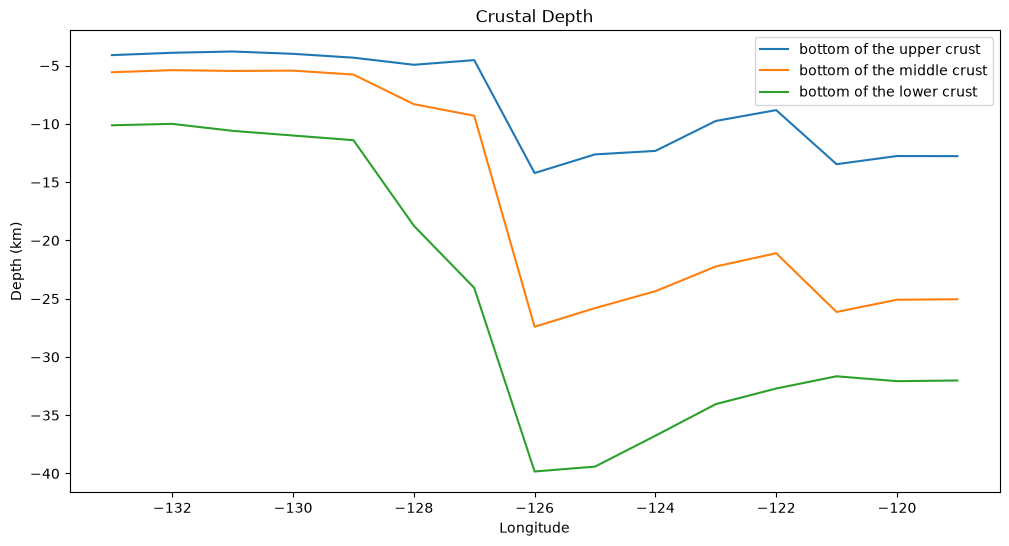

In [17]:
lat = 50

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(all[lat]['long'], all[lat]['z_up'], label='bottom of the upper crust')
ax.plot(all[lat]['long'], all[lat]['z_mid'], label='bottom of the middle crust')
ax.plot(all[lat]['long'], all[lat]['z_low'], label='bottom of the lower crust')

ax.set_xlabel('Longitude')
ax.set_ylabel('Depth (km)')
ax.set_title('Crustal Depth')
ax.legend()
plt.show()